In [ ]:
from pathlib import Path
import json
EXPERIMENT_DIR = '/Users/nyuad/Desktop/capstone/experiments/baseline_social/run_0001/experiment.json'


GT = (
    "University media crews record interviews and highlights across the career fair floor."
    "Recruiters distribute tote bags, notebooks, tech swag, and follow-up instructions."
    "Startups schedule lunchtime pitch sessions while international students receive visa guidance."
    "Whiteboards and dashboards track interview slots, attendance numbers, and recruiter availability."
    "Nonprofits share mission-driven roles beside corporate employers, emphasizing varied career paths. "
    "Students upload resumes at digital kiosks tied to the fair database."
    "The dean thanks recruiters while career center staff log metrics on laptops."
    "Chimes announce the final hour as recruiters encourage personalized email follow-ups."
    "Volunteers pack booths and collect leftover brochures at the end of the day."
    "Students depart with stacks of business cards, survey links, and notes on responsive recruiters."
    "Friends debrief on the quad, comparing impressions of company cultures and enthusiasm."
    "Post-event planning focuses on scheduling interviews and sustaining new connections."
)


experiment_data = json.loads(Path(EXPERIMENT_DIR).read_text())


from sentence_transformers import CrossEncoder
model = CrossEncoder('cross-encoder/nli-deberta-v3-large')
scores = model.predict([('I am going to Portland to herd to sheeps', 'I love hicking in the mountains in Portland')])

In [19]:
scores

array([[-3.2820609, -3.8473732,  5.42258  ]], dtype=float32)

In [27]:
import numpy as np
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

softmax(scores)



array([[1.6577147e-04, 9.4188472e-05, 9.9974006e-01]], dtype=float32)

In [40]:
import re
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
LABELS = ["contradiction", "entailment", "neutral"]
def decompose_into_sentences(text):
    sentences = re.split(r'[.!?]', text.strip())

    return [s for s in sentences]

gt_claims = decompose_into_sentences(GT) # we just need to compute this once

def evalute_coverage(gt_claims: list[str], agent_summary: str):
    agent_sentences = decompose_into_sentences(agent_summary)
    print(f"gt_claims: {gt_claims}, {len(gt_claims)}")
    print(f"agent_sentences: {agent_sentences}, {len(agent_sentences)}")

    coverage_matrix = np.zeros((len(agent_sentences), len(gt_claims)))
    accuracy_matrix = np.zeros((len(agent_sentences), len(gt_claims)))

    
    for i, claim in enumerate(gt_claims):
        for j, sentence in enumerate(agent_sentences):
            logits_coverage = model.predict([(sentence, claim)])[0]
            probs_coverage = softmax(logits_coverage)

            logits_accuracy = model.predict([(claim, sentence)])[0]
            probs_accuracy = softmax(logits_accuracy)

            coverage_matrix[j, i] = float(probs_coverage[1])
            accuracy_matrix[j, i] = float(probs_accuracy[1])

    return coverage_matrix, accuracy_matrix

def print_matrix(matrix, row_labels=None, col_labels=None, title="", max_label_len=50):
    
    mat = np.array(matrix)
    n_rows, n_cols = mat.shape

    if row_labels is None:
        row_labels = [f"S{i}" for i in range(n_rows)]
    if col_labels is None:
        col_labels = [f"F{j}" for j in range(n_cols)]

    def _trunc(s, n=max_label_len):
        s = s.strip()
        return s if len(s) <= n else s[:n].rsplit(" ", 1)[0] + "…"

    row_labels = [_trunc(l) for l in row_labels]
    col_labels = [_trunc(l) for l in col_labels]

    cell_w = max(1.4, min(2.2, 20.0 / n_cols))
    cell_h = max(0.6, min(1.2, 14.0 / n_rows))
    fig_w = max(10, n_cols * cell_w + 4)
    fig_h = max(4, n_rows * cell_h + 3)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")

    cmap = LinearSegmentedColormap.from_list(
        "blue_red", ["#1e3a5f", "#3b7dd8", "#f0f0f0", "#e8644a", "#c0392b"]
    )
    im = ax.imshow(mat, cmap=cmap, aspect="auto", vmin=0, vmax=1)

    for i in range(n_rows):
        for j in range(n_cols):
            val = mat[i, j]
            color = "white" if val < 0.35 or val > 0.75 else "#1a1a2e"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=max(6, min(9, 100 // max(n_rows, n_cols))),
                    color=color, fontweight="bold")

    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(col_labels, rotation=45, ha="right", fontsize=7, color="#c9d1d9")
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels, fontsize=7, color="#c9d1d9")

    if title:
        ax.set_title(title, fontsize=14, color="#ffffff", fontweight="bold", pad=12)

    cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.04)
    cbar.ax.tick_params(colors="#8b949e", labelsize=8)

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()






gt_claims: ['University media crews record interviews and highlights across the career fair floor', ' Recruiters distribute tote bags, notebooks, tech swag, and follow-up instructions', ' Startups schedule lunchtime pitch sessions while international students receive visa guidance', ' Whiteboards and dashboards track interview slots, attendance numbers, and recruiter availability', ' Nonprofits share mission-driven roles beside corporate employers, emphasizing varied career paths', ' Students upload resumes at digital kiosks tied to the fair database', ' The dean thanks recruiters while career center staff log metrics on laptops', ' Chimes announce the final hour as recruiters encourage personalized email follow-ups', ' Volunteers pack booths and collect leftover brochures at the end of the day', ' Students depart with stacks of business cards, survey links, and notes on responsive recruiters', ' Friends debrief on the quad, comparing impressions of company cultures and enthusiasm', ' 

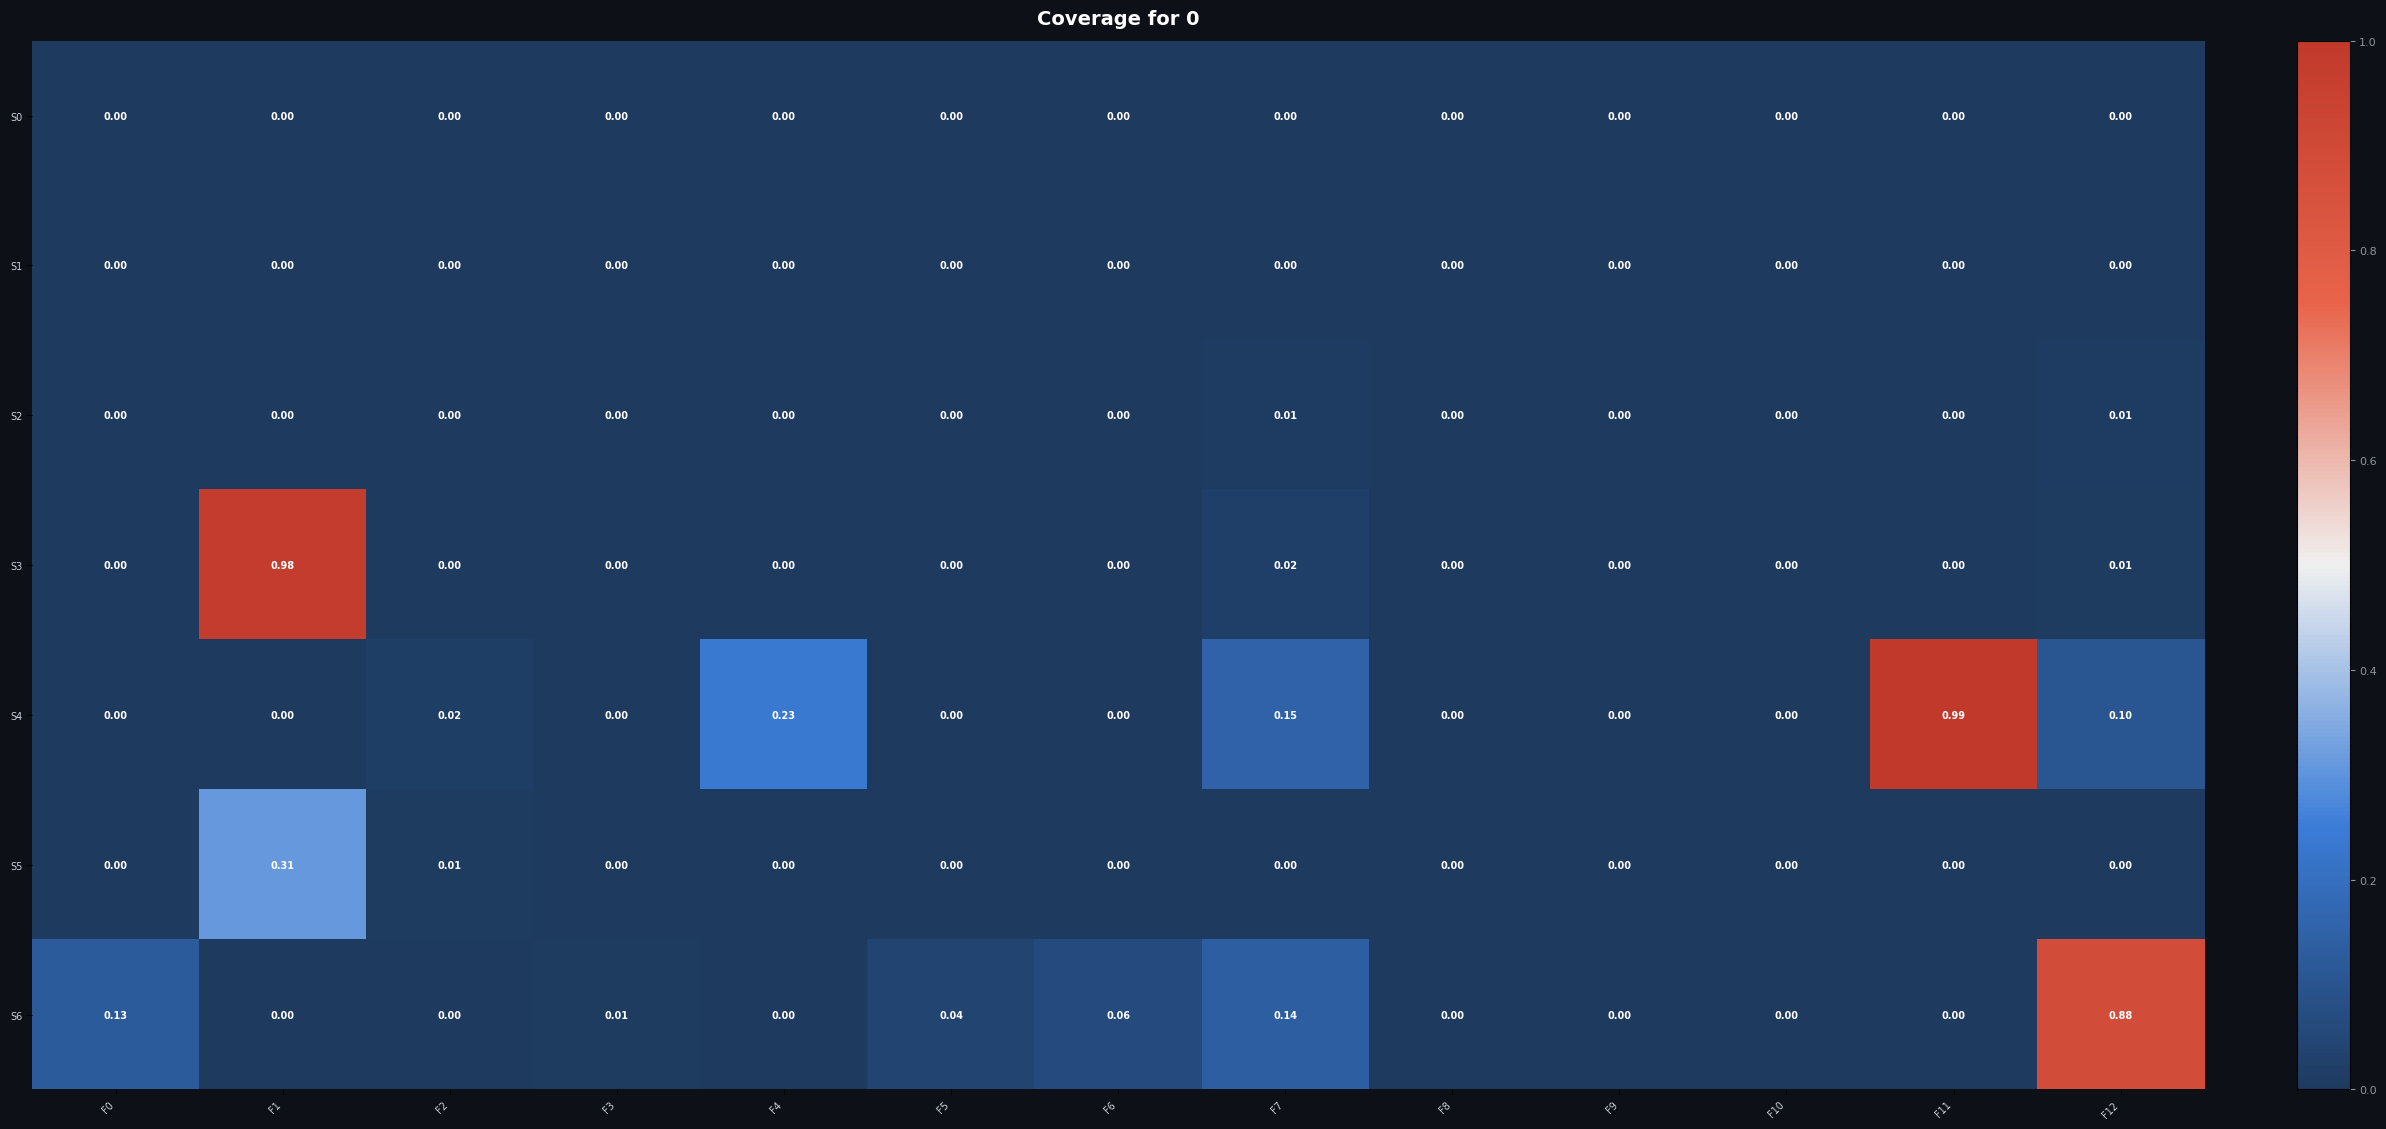

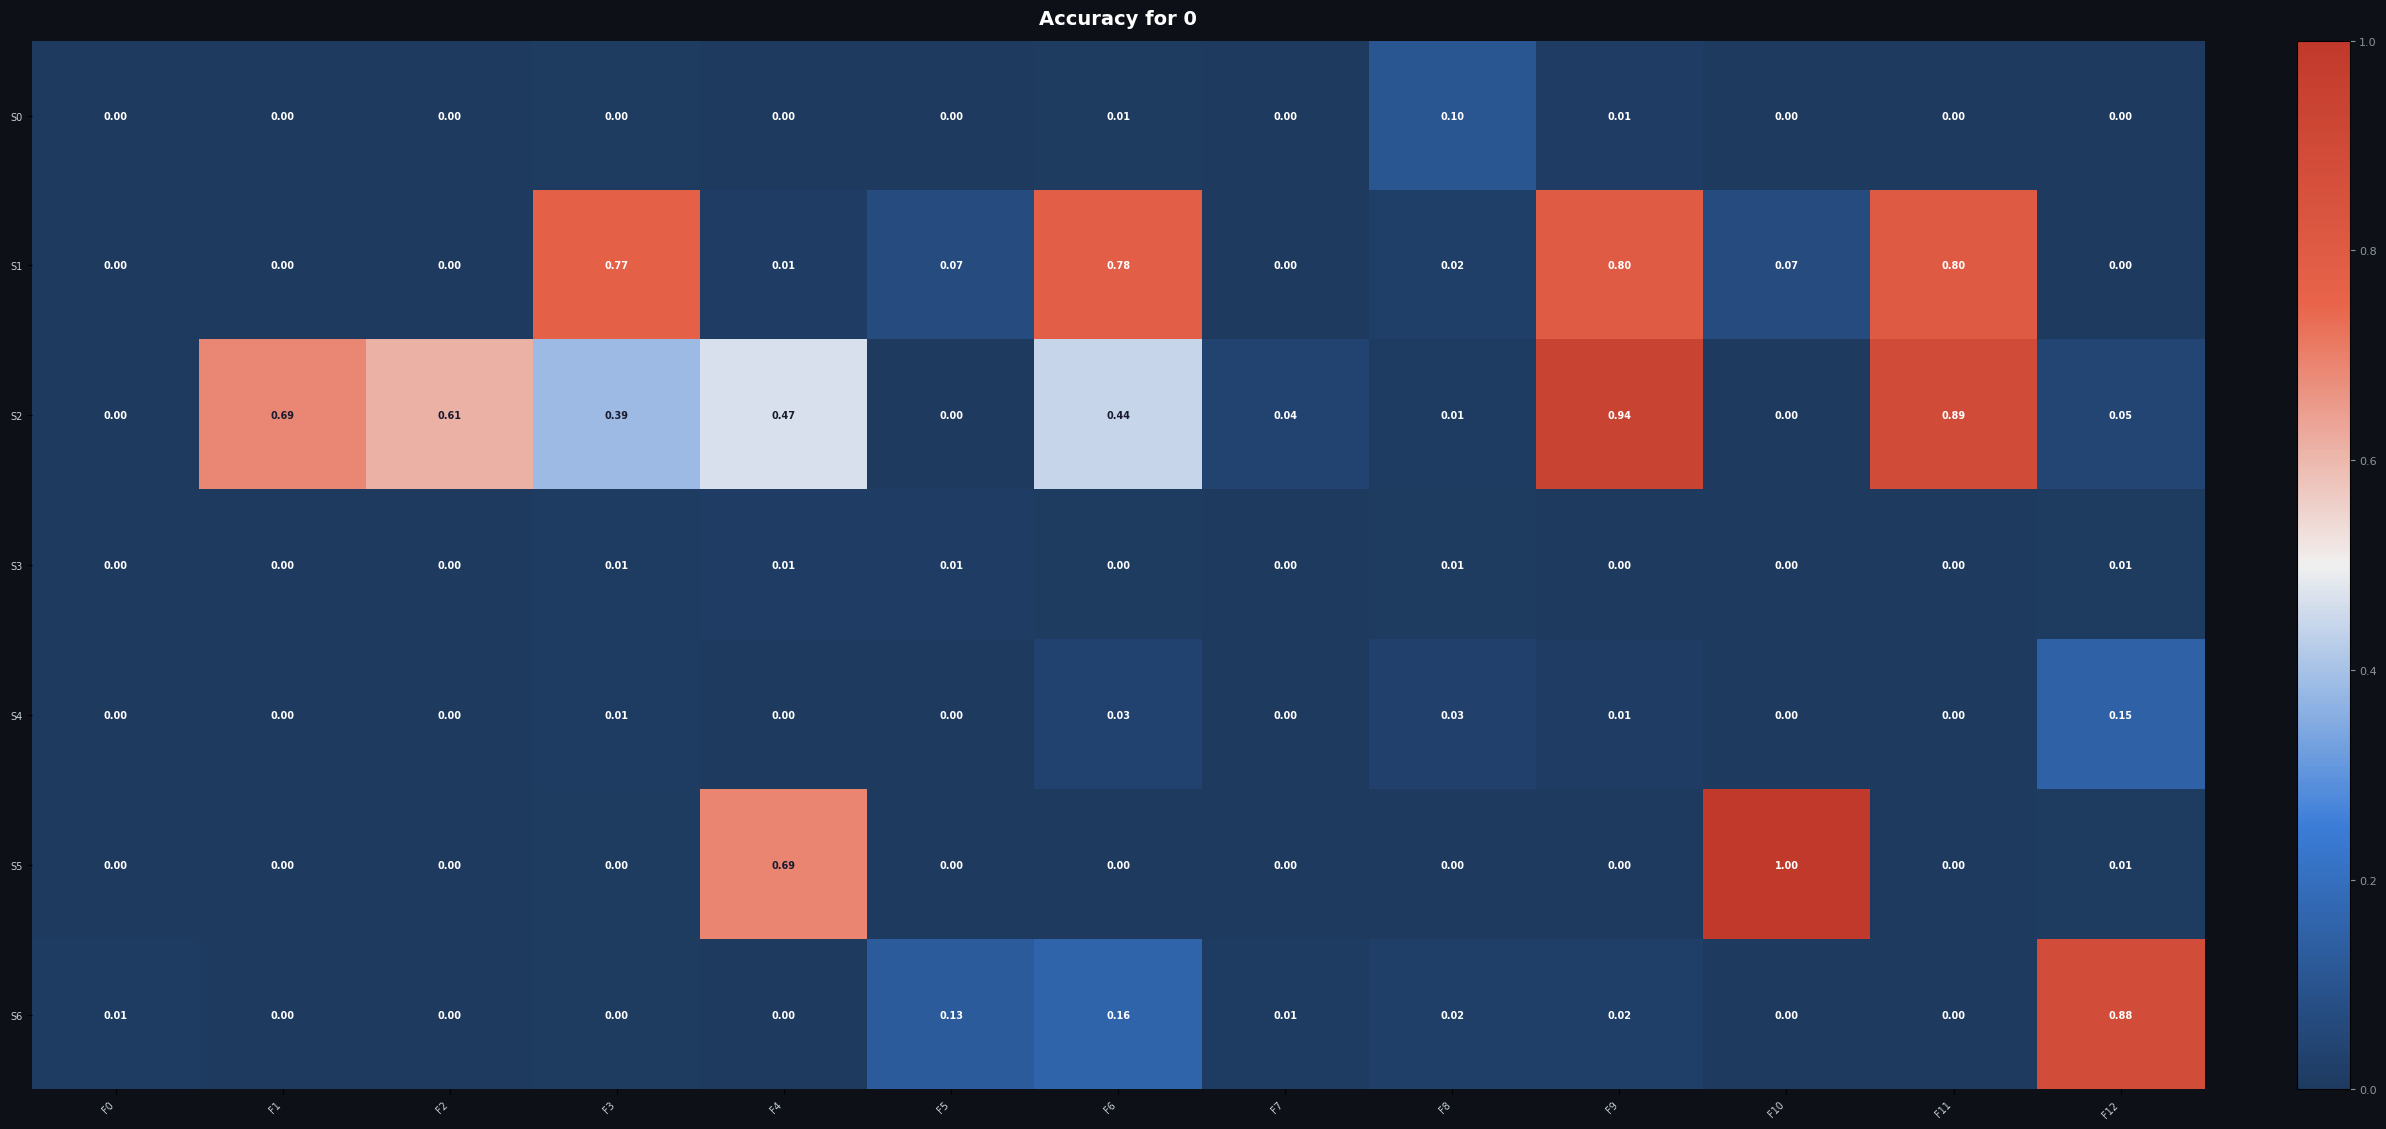

In [41]:
agents_data = experiment_data['agents']

for agent_id, agent_data in agents_data.items():
    summary_data = agent_data['summaries']
    summaries = list(summary_data.values())
    last_summary = summaries[-1]
    coverage_matrix, accuracy_matrix = evalute_coverage(gt_claims, last_summary)
    print_matrix(coverage_matrix, title=f"Coverage for {agent_id}")
    print_matrix(accuracy_matrix, title=f"Accuracy for {agent_id}")
    break